# 🏠 House Price Prediction Project

##  Objective

* To build a machine learning model that predicts house prices
* To analyze how different property features affect price
* To apply regression techniques for real-world prediction
* To evaluate model performance using error metrics

---

##  Dataset

* Contains house-related property data
* Features include:

  * Area (square footage)
  * Number of bedrooms
  * Number of bathrooms
  * Parking spaces
  * Furnishing status
* Target variable:

  * Price (house value)

---

##  Libraries Used

* Pandas → Data loading and manipulation
* NumPy → Numerical computations
* Matplotlib → Data visualization
* Scikit-learn → Machine learning tools

  * Train-test split
  * StandardScaler
  * Linear Regression
  * Gradient Boosting Regressor
  * Evaluation metrics (MAE, RMSE)

---

## Project Workflow

* Load dataset
* Perform data exploration
* Handle categorical variables
* Apply feature scaling
* Split data into training and testing sets
* Train regression model
* Make predictions
* Evaluate performance
* Visualize results



# Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load Dataset

In [ ]:
df = pd.read_csv('Housing.csv')
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


# Data Checking

In [ ]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


# Convert Categorical Data

In [ ]:
df = pd.read_csv('Housing.csv')

# Map binary features safely
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

#  Handle 'furnishingstatus' using One-Hot Encoding
# drop_first=True prevents the "dummy variable trap"
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

# Display the result to confirm numbers are there
print("Columns now available:", df.columns.tolist())
df.head()

Columns now available: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


# Features & Target

In [ ]:
X = df.drop('price', axis=1)
y = df['price']

# Feature Scaling

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

# Train Models

In [ ]:

# Linear Regression Model

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)


# Gradient Boosting Model

gb_model = GradientBoostingRegressor()
gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

# Accuracy Comparison Table

In [ ]:
# Linear Regression Metrics
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

# Gradient Boosting Metrics
gb_mae = mean_absolute_error(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))

# Create comparison table
results = pd.DataFrame({
    "Model": ["Linear Regression", "Gradient Boosting"],
    "MAE": [lr_mae, gb_mae],
    "RMSE": [lr_rmse, gb_rmse]
})

print(results)

               Model            MAE          RMSE
0  Linear Regression  970043.403920  1.324507e+06
1  Gradient Boosting  958407.632981  1.298244e+06


# Error Distribution Graph

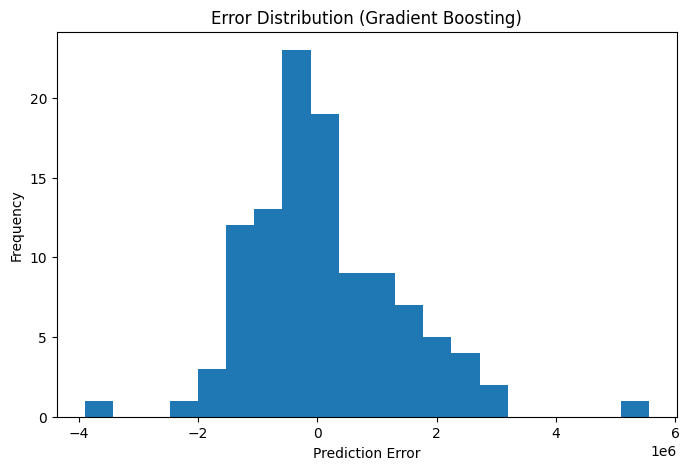

In [ ]:
errors = y_test - gb_pred

plt.figure(figsize=(8,5))
plt.hist(errors, bins=20)
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Error Distribution (Gradient Boosting)")
plt.show()

# Evaluation Metrics


In [37]:
mae = mean_absolute_error(y_test, gb_pred)
rmse = np.sqrt(mean_squared_error(y_test, gb_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 958407.6329807763
RMSE: 1298243.696822947


# Visualization

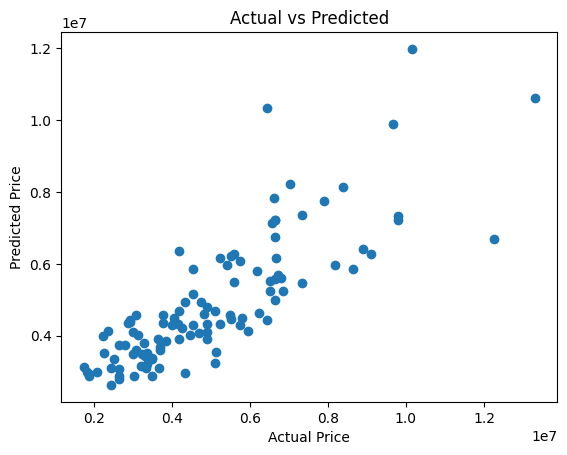

In [ ]:
plt.scatter(y_test, gb_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()



# Line Comparison

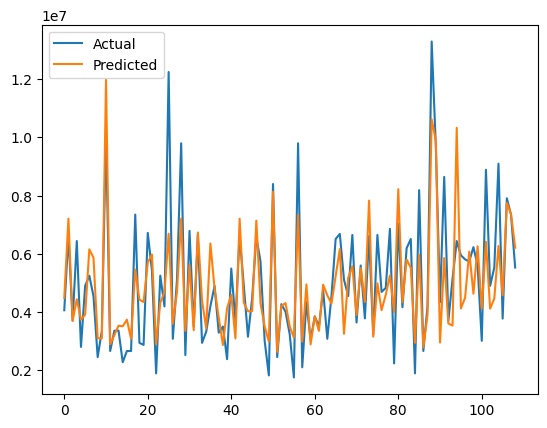

In [ ]:
plt.plot(y_test.values, label="Actual")
plt.plot(gb_pred, label="Predicted")
plt.legend()
plt.show()

# Feature Importance

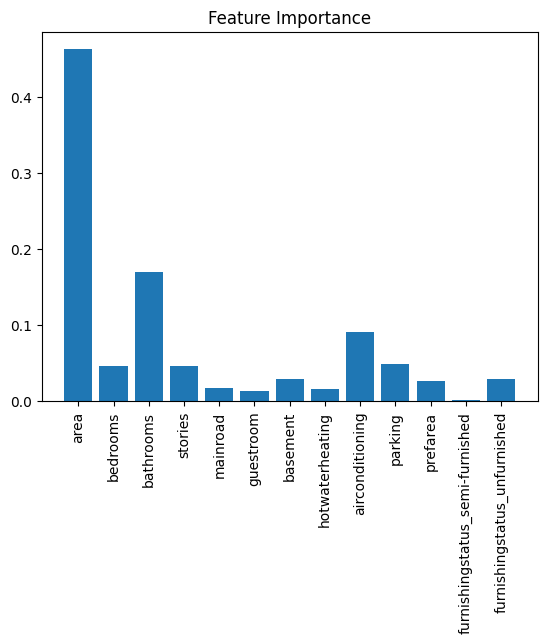

In [38]:
importance = model.feature_importances_

plt.bar(X.columns, importance)
plt.xticks(rotation=90)
plt.title("Feature Importance")
plt.show()

##  Conclusion

- This project successfully built a machine learning model to predict house prices using key property features such as area, bedrooms, bathrooms, parking, and furnishing status.  
- Two models were implemented: Linear Regression and Gradient Boosting Regressor.  
- After evaluation, Gradient Boosting performed better with lower MAE and RMSE values, making it the more accurate model.  
- The results show that features like area, number of rooms, and parking significantly influence house prices.  
- Visualizations such as Actual vs Predicted plots and Error Distribution graphs helped in understanding model performance clearly.  
- Overall, this project demonstrates how regression techniques can be effectively used for real-world house price prediction.